<a href="https://colab.research.google.com/github/elias8080007/Syntecxhub_Maze_Solver/blob/main/maze_solver_astar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maze Solver Using A-Star Search

Syntecxhub Artificial Intelligence Internship  
Week 1 Project  
Developed by Elias Elias

## 1. Project Overview

This project implements the A-Star search algorithm to find the shortest path between a starting position and a goal position inside a maze.

The maze is represented as a two-dimensional grid containing open cells, walls, a starting position, and a goal position.

A-Star evaluates each possible node using the following function:

$$
f(n) = g(n) + h(n)
$$

Where:

- $f(n)$ represents the estimated total path cost.
- $g(n)$ represents the actual cost from the starting node to node $n$.
- $h(n)$ represents the estimated cost from node $n$ to the goal.

## 2. Project Objectives

- Represent the maze as a two-dimensional grid.
- Define the starting position, goal position, and walls.
- Implement the A-Star search algorithm.
- Use Manhattan distance as the heuristic function.
- Find and reconstruct the shortest available path.
- Handle cases where the goal cannot be reached.
- Visualize the maze and the final shortest path.

## 3. Maze Representation

The maze uses the following values:

- `0` represents an open cell that can be visited.
- `1` represents a wall that cannot be crossed.

The starting and goal positions are represented as coordinate pairs:

$$
\text{Position} = (\text{row},\text{column})
$$

## 4. Importing the Required Libraries

The project uses a priority queue to select the most promising node, NumPy to represent the maze, and Matplotlib to visualize the maze and the resulting path.

In [1]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("Libraries imported successfully.")

Libraries imported successfully.


## 5. Defining the Maze

The maze is represented as a NumPy array. Open cells have a value of `0`, while walls have a value of `1`.

The search begins at the top-left corner and attempts to reach the bottom-right corner.

In [2]:
maze = np.array([
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 0, 0, 1, 0]
])

start = (0, 0)
goal = (9, 9)

print("Maze dimensions:", maze.shape)
print("Starting position:", start)
print("Goal position:", goal)
print("\nMaze:\n", maze)

Maze dimensions: (10, 10)
Starting position: (0, 0)
Goal position: (9, 9)

Maze:
 [[0 0 0 1 0 0 0 0 0 0]
 [1 1 0 1 0 1 1 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 1 1 1 1 1 1 0 1 0]
 [0 0 0 0 0 0 1 0 0 0]
 [1 1 1 1 1 0 1 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 1 1 1 1 1 1 0 1 0]
 [0 0 0 0 0 0 1 0 0 0]
 [1 1 1 1 1 0 0 0 1 0]]


## 6. Visualizing the Maze

Before applying the search algorithm, the original maze is displayed to show the open cells, walls, starting position, and goal position.

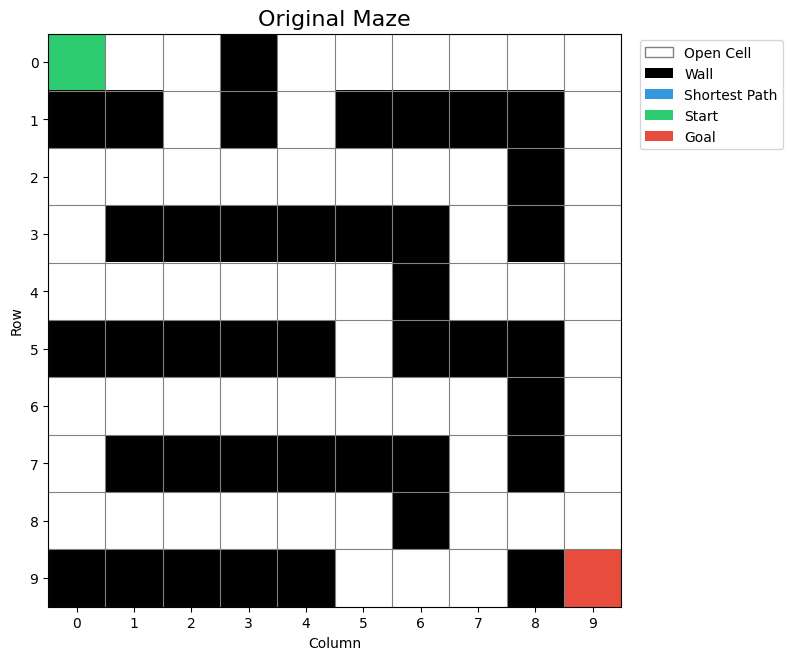

In [3]:
from matplotlib.patches import Patch


def visualize_maze(maze, start, goal, path=None, title="Maze"):
    visual_maze = maze.copy()

    if path is not None:
        for row, column in path:
            visual_maze[row, column] = 2

    visual_maze[start] = 3
    visual_maze[goal] = 4

    colors = ListedColormap([
        "white",      # Open cell
        "black",      # Wall
        "#3498DB",    # Shortest path
        "#2ECC71",    # Starting position
        "#E74C3C"     # Goal position
    ])

    figure, axis = plt.subplots(figsize=(8, 8))

    axis.imshow(
        visual_maze,
        cmap=colors,
        vmin=0,
        vmax=4
    )

    axis.set_xticks(range(maze.shape[1]))
    axis.set_yticks(range(maze.shape[0]))

    axis.set_xticks(
        np.arange(-0.5, maze.shape[1], 1),
        minor=True
    )
    axis.set_yticks(
        np.arange(-0.5, maze.shape[0], 1),
        minor=True
    )

    axis.grid(
        which="minor",
        color="gray",
        linewidth=0.8
    )

    axis.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    legend_items = [
        Patch(facecolor="white", edgecolor="gray", label="Open Cell"),
        Patch(facecolor="black", label="Wall"),
        Patch(facecolor="#3498DB", label="Shortest Path"),
        Patch(facecolor="#2ECC71", label="Start"),
        Patch(facecolor="#E74C3C", label="Goal")
    ]

    axis.legend(
        handles=legend_items,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    axis.set_title(title, fontsize=16)
    axis.set_xlabel("Column")
    axis.set_ylabel("Row")

    plt.tight_layout()
    plt.show()


visualize_maze(
    maze,
    start,
    goal,
    title="Original Maze"
)

## 7. Manhattan Distance Heuristic

The Manhattan distance estimates the remaining cost between the current node and the goal node.

It calculates the total horizontal and vertical distance between two positions:

$$
h(n) = |r_n-r_g| + |c_n-c_g|
$$

Where:

- $r_n$ and $c_n$ represent the row and column of the current node.
- $r_g$ and $c_g$ represent the row and column of the goal node.

This heuristic is suitable because movement inside the maze is limited to four directions: up, down, left, and right.

In [4]:
def manhattan_distance(position, goal):
    row_distance = abs(position[0] - goal[0])
    column_distance = abs(position[1] - goal[1])

    return row_distance + column_distance


start_estimate = manhattan_distance(start, goal)

print("Estimated distance from start to goal:", start_estimate)

Estimated distance from start to goal: 18


## 8. Finding Valid Neighboring Cells

From each current position, the algorithm can attempt to move in four directions:

- Up
- Down
- Left
- Right

A neighboring cell is considered valid when it is located inside the maze boundaries and is not a wall.

In [5]:
def get_valid_neighbors(position, maze):
    row, column = position

    directions = [
        (-1, 0),  # Up
        (1, 0),   # Down
        (0, -1),  # Left
        (0, 1)    # Right
    ]

    valid_neighbors = []

    for row_change, column_change in directions:
        new_row = row + row_change
        new_column = column + column_change

        inside_maze = (
            0 <= new_row < maze.shape[0]
            and 0 <= new_column < maze.shape[1]
        )

        if inside_maze and maze[new_row, new_column] == 0:
            valid_neighbors.append((new_row, new_column))

    return valid_neighbors


print(
    "Valid neighbors of the starting position:",
    get_valid_neighbors(start, maze)
)

print(
    "Valid neighbors of position (2, 2):",
    get_valid_neighbors((2, 2), maze)
)

Valid neighbors of the starting position: [(0, 1)]
Valid neighbors of position (2, 2): [(1, 2), (2, 1), (2, 3)]


## 9. Implementing the A-Star Search Algorithm

The A-Star algorithm maintains a priority queue containing the nodes that may be explored.

For every node, the algorithm calculates:

$$
f(n) = g(n) + h(n)
$$

The node with the lowest estimated total cost is explored first.

The algorithm also records the parent of every visited node so that the shortest path can be reconstructed after reaching the goal.

In [6]:
def reconstruct_paths(came_from, goal_position):
    backward_path = [goal_position]
    current_position = goal_position

    while current_position in came_from:
        current_position = came_from[current_position]
        backward_path.append(current_position)

    forward_path = list(reversed(backward_path))

    return backward_path, forward_path


def a_star_search(maze, start, goal):
    rows, columns = maze.shape

    def is_inside_maze(position):
        row, column = position

        return (
            0 <= row < rows
            and 0 <= column < columns
        )

    if not is_inside_maze(start):
        raise ValueError("The starting position is outside the maze.")

    if not is_inside_maze(goal):
        raise ValueError("The goal position is outside the maze.")

    if maze[start] == 1:
        raise ValueError("The starting position cannot be a wall.")

    if maze[goal] == 1:
        raise ValueError("The goal position cannot be a wall.")

    open_queue = []

    starting_priority = manhattan_distance(start, goal)

    heapq.heappush(
        open_queue,
        (starting_priority, 0, start)
    )

    came_from = {}
    movement_cost = {start: 0}
    explored_positions = set()
    exploration_order = []

    while open_queue:
        estimated_total_cost, current_cost, current_position = (
            heapq.heappop(open_queue)
        )

        if current_position in explored_positions:
            continue

        explored_positions.add(current_position)
        exploration_order.append(current_position)

        if current_position == goal:
            backward_path, forward_path = reconstruct_paths(
                came_from,
                current_position
            )

            return forward_path, backward_path, exploration_order

        valid_neighbors = get_valid_neighbors(
            current_position,
            maze
        )

        for neighbor in valid_neighbors:
            if neighbor in explored_positions:
                continue

            new_movement_cost = movement_cost[current_position] + 1

            previous_cost = movement_cost.get(
                neighbor,
                float("inf")
            )

            if new_movement_cost < previous_cost:
                came_from[neighbor] = current_position
                movement_cost[neighbor] = new_movement_cost

                heuristic_cost = manhattan_distance(
                    neighbor,
                    goal
                )

                total_estimated_cost = (
                    new_movement_cost + heuristic_cost
                )

                heapq.heappush(
                    open_queue,
                    (
                        total_estimated_cost,
                        new_movement_cost,
                        neighbor
                    )
                )

    return None, None, exploration_order

## 10. Finding and Visualizing the Shortest Path

The A-Star search function is now applied to the maze.

If the goal is reachable, the program displays the shortest path, its total number of movements, the number of explored nodes, and a visual representation of the result.

Shortest path found successfully.
Number of movements: 18
Number of explored nodes: 19

Backward path from goal to start:
[(9, 9), (8, 9), (7, 9), (6, 9), (5, 9), (4, 9), (4, 8), (4, 7), (3, 7), (2, 7), (2, 6), (2, 5), (2, 4), (2, 3), (2, 2), (1, 2), (0, 2), (0, 1), (0, 0)]

Forward path from start to goal:
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 7), (4, 7), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


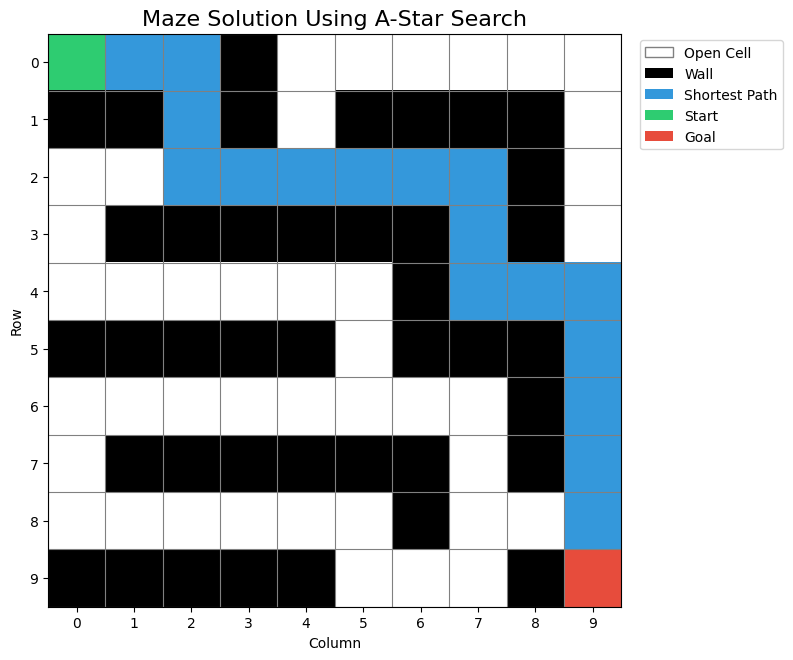

In [7]:
forward_path, backward_path, exploration_order = a_star_search(
    maze,
    start,
    goal
)

if forward_path is not None:
    number_of_movements = len(forward_path) - 1
    explored_nodes = len(exploration_order)

    print("Shortest path found successfully.")
    print("Number of movements:", number_of_movements)
    print("Number of explored nodes:", explored_nodes)

    print("\nBackward path from goal to start:")
    print(backward_path)

    print("\nForward path from start to goal:")
    print(forward_path)

    visualize_maze(
        maze,
        start,
        goal,
        path=forward_path,
        title="Maze Solution Using A-Star Search"
    )

else:
    print("No path exists between the start and goal positions.")
    print("Number of explored nodes:", len(exploration_order))

## 11. Animated Search Exploration and Path Reconstruction

The animation demonstrates the complete search process in three stages:

1. Yellow cells show the nodes explored by the algorithm.
2. Purple cells show the backward reconstruction from the goal to the start.
3. Blue cells show the final forward path from the start to the goal.

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from matplotlib.patches import Patch


def animate_maze_search(
    maze,
    start,
    goal,
    exploration_order,
    backward_path,
    forward_path,
    interval=180
):
    color_map = ListedColormap([
        "white",      # Open cell
        "black",      # Wall
        "#F1C40F",    # Explored cell
        "#9B59B6",    # Backward path
        "#3498DB",    # Forward path
        "#2ECC71",    # Start
        "#E74C3C"     # Goal
    ])

    figure, axis = plt.subplots(figsize=(9, 7))

    image = axis.imshow(
        maze,
        cmap=color_map,
        vmin=0,
        vmax=6
    )

    axis.set_xticks(range(maze.shape[1]))
    axis.set_yticks(range(maze.shape[0]))

    axis.set_xticks(
        np.arange(-0.5, maze.shape[1], 1),
        minor=True
    )
    axis.set_yticks(
        np.arange(-0.5, maze.shape[0], 1),
        minor=True
    )

    axis.grid(
        which="minor",
        color="gray",
        linewidth=0.8
    )

    axis.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    axis.set_xlabel("Column")
    axis.set_ylabel("Row")

    legend_items = [
        Patch(facecolor="white", edgecolor="gray", label="Open Cell"),
        Patch(facecolor="black", label="Wall"),
        Patch(facecolor="#F1C40F", label="Explored Cell"),
        Patch(facecolor="#9B59B6", label="Backward Path"),
        Patch(facecolor="#3498DB", label="Forward Path"),
        Patch(facecolor="#2ECC71", label="Start"),
        Patch(facecolor="#E74C3C", label="Goal")
    ]

    axis.legend(
        handles=legend_items,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    exploration_frames = len(exploration_order)
    backward_frames = len(backward_path)
    forward_frames = len(forward_path)

    total_frames = (
        exploration_frames
        + backward_frames
        + forward_frames
        + 1
    )

    def update_frame(frame_number):
        visual_maze = maze.copy()

        explored_limit = min(
            frame_number,
            exploration_frames
        )

        for position in exploration_order[:explored_limit]:
            if position not in (start, goal):
                visual_maze[position] = 2

        if frame_number <= exploration_frames:
            axis.set_title(
                f"Exploring the Maze: "
                f"{explored_limit} of {exploration_frames} nodes"
            )

        elif frame_number <= exploration_frames + backward_frames:
            backward_limit = (
                frame_number - exploration_frames
            )

            for position in backward_path[:backward_limit]:
                if position not in (start, goal):
                    visual_maze[position] = 3

            axis.set_title(
                f"Reconstructing Backward Path: "
                f"{backward_limit} of {backward_frames} cells"
            )

        else:
            for position in backward_path:
                if position not in (start, goal):
                    visual_maze[position] = 3

            forward_limit = (
                frame_number
                - exploration_frames
                - backward_frames
            )

            for position in forward_path[:forward_limit]:
                if position not in (start, goal):
                    visual_maze[position] = 4

            axis.set_title(
                f"Building Forward Path: "
                f"{forward_limit} of {forward_frames} cells"
            )

        visual_maze[start] = 5
        visual_maze[goal] = 6

        image.set_data(visual_maze)

        return image,

    search_animation = FuncAnimation(
        figure,
        update_frame,
        frames=range(total_frames),
        interval=interval,
        repeat=False,
        blit=False
    )

    plt.close(figure)

    return search_animation

In [9]:
if forward_path is not None:
    maze_animation = animate_maze_search(
        maze,
        start,
        goal,
        exploration_order,
        backward_path,
        forward_path,
        interval=180
    )

    display(
        HTML(maze_animation.to_jshtml())
    )

else:
    print("The animation cannot be created because no path was found.")

## 12. Interactive Maze Editor

This interactive editor allows the user to modify the maze without changing the source code manually.

Clicking a cell changes it between an open cell and a wall. The user can also choose different starting and goal positions before running the A-Star search.
Click on the maze result to see the live footage.

In [10]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output


def create_interactive_maze_editor(
    initial_maze,
    initial_start,
    initial_goal
):
    initial_maze = np.array(initial_maze, dtype=int)

    rows, columns = initial_maze.shape
    cell_buttons = {}

    for row in range(rows):
        for column in range(columns):
            cell_value = int(initial_maze[row, column])

            cell_button = widgets.ToggleButton(
                value=bool(cell_value),
                description=str(cell_value),
                tooltip=f"Cell ({row}, {column})",
                layout=widgets.Layout(
                    width="40px",
                    height="40px",
                    margin="1px"
                )
            )

            if cell_value == 1:
                cell_button.button_style = "danger"

            def update_cell(change, button=cell_button):
                if change["new"]:
                    button.description = "1"
                    button.button_style = "danger"
                else:
                    button.description = "0"
                    button.button_style = ""

            cell_button.observe(
                update_cell,
                names="value"
            )

            cell_buttons[(row, column)] = cell_button

    maze_grid = widgets.GridBox(
        children=list(cell_buttons.values()),
        layout=widgets.Layout(
            grid_template_columns=f"repeat({columns}, 42px)",
            grid_gap="1px"
        )
    )

    available_positions = [
        (
            f"({row}, {column})",
            (row, column)
        )
        for row in range(rows)
        for column in range(columns)
    ]

    start_selector = widgets.Dropdown(
        options=available_positions,
        value=initial_start,
        description="Start:"
    )

    goal_selector = widgets.Dropdown(
        options=available_positions,
        value=initial_goal,
        description="Goal:"
    )

    solve_button = widgets.Button(
        description="Solve Maze",
        button_style="success",
        icon="play"
    )

    reset_button = widgets.Button(
        description="Reset Maze",
        button_style="warning",
        icon="refresh"
    )

    output_area = widgets.Output()

    def read_edited_maze():
        edited_maze = np.zeros(
            (rows, columns),
            dtype=int
        )

        for row in range(rows):
            for column in range(columns):
                edited_maze[row, column] = int(
                    cell_buttons[(row, column)].value
                )

        return edited_maze

    def solve_edited_maze(button):
        with output_area:
            clear_output(wait=True)

            edited_maze = read_edited_maze()
            selected_start = start_selector.value
            selected_goal = goal_selector.value

            try:
                (
                    edited_forward_path,
                    edited_backward_path,
                    edited_exploration_order
                ) = a_star_search(
                    edited_maze,
                    selected_start,
                    selected_goal
                )

                if edited_forward_path is None:
                    print(
                        "No path exists between the selected "
                        "start and goal positions."
                    )

                    print(
                        "Explored nodes:",
                        len(edited_exploration_order)
                    )

                    visualize_maze(
                        edited_maze,
                        selected_start,
                        selected_goal,
                        title="Unreachable Maze"
                    )

                else:
                    print("Shortest path found successfully.")

                    print(
                        "Number of movements:",
                        len(edited_forward_path) - 1
                    )

                    print(
                        "Number of explored nodes:",
                        len(edited_exploration_order)
                    )

                    visualize_maze(
                        edited_maze,
                        selected_start,
                        selected_goal,
                        path=edited_forward_path,
                        title="Custom Maze Solution"
                    )

                    custom_animation = animate_maze_search(
                        edited_maze,
                        selected_start,
                        selected_goal,
                        edited_exploration_order,
                        edited_backward_path,
                        edited_forward_path,
                        interval=180
                    )

                    display(
                        HTML(custom_animation.to_jshtml())
                    )

            except ValueError as error:
                print("Invalid maze configuration:")
                print(error)

    def reset_editor(button):
        for row in range(rows):
            for column in range(columns):
                cell_buttons[(row, column)].value = bool(
                    initial_maze[row, column]
                )

        start_selector.value = initial_start
        goal_selector.value = initial_goal

        with output_area:
            clear_output()

        print("The maze editor was reset.")

    solve_button.on_click(solve_edited_maze)
    reset_button.on_click(reset_editor)

    instructions = widgets.HTML(
        value="""
        <p>
        Click a cell to switch between 0 and 1.
        Red buttons represent walls.
        Select the start and goal positions, then click Solve Maze.
        </p>
        """
    )

    controls = widgets.HBox([
        start_selector,
        goal_selector
    ])

    action_buttons = widgets.HBox([
        solve_button,
        reset_button
    ])

    display(
        widgets.VBox([
            instructions,
            maze_grid,
            controls,
            action_buttons,
            output_area
        ])
    )


create_interactive_maze_editor(
    maze,
    start,
    goal
)